In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data, img_as_ubyte

In [4]:
# 1. Load a Standard High-Res Image (The "Astronaut")
clean_img = img_as_ubyte(data.astronaut())
clean_img = cv2.cvtColor(clean_img, cv2.COLOR_RGB2GRAY) # Convert to Grayscale for clarity

In [5]:
# 2. Simulate "Low Light Camera" Noise (High ISO)
def add_heavy_noise(image):
    row, col = image.shape
    mean = 0
    var = 600 # Heavy noise
    sigma = var ** 0.5
    gauss = np.random.normal(mean, sigma, (row, col))
    noisy = image + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

noisy_img = add_heavy_noise(clean_img)

In [6]:
# 3. Apply the Linear Filters
# Box Filter (The "Sledgehammer")
blur_box = cv2.blur(noisy_img, (5, 5))

# Gaussian Filter (The "Precise Hammer")
blur_gauss = cv2.GaussianBlur(noisy_img, (5, 5), 0)

In [7]:
# 4. Zoom in on a critical detail (The Flag Patch) to see the damage
# We crop a specific region to show the texture loss clearly
y1, y2, x1, x2 = 0, 200, 0, 200 # Top left corner (stars/flag area)
crop_clean = clean_img[y1:y2, x1:x2]
crop_noisy = noisy_img[y1:y2, x1:x2]
crop_box   = blur_box[y1:y2, x1:x2]
crop_gauss = blur_gauss[y1:y2, x1:x2]

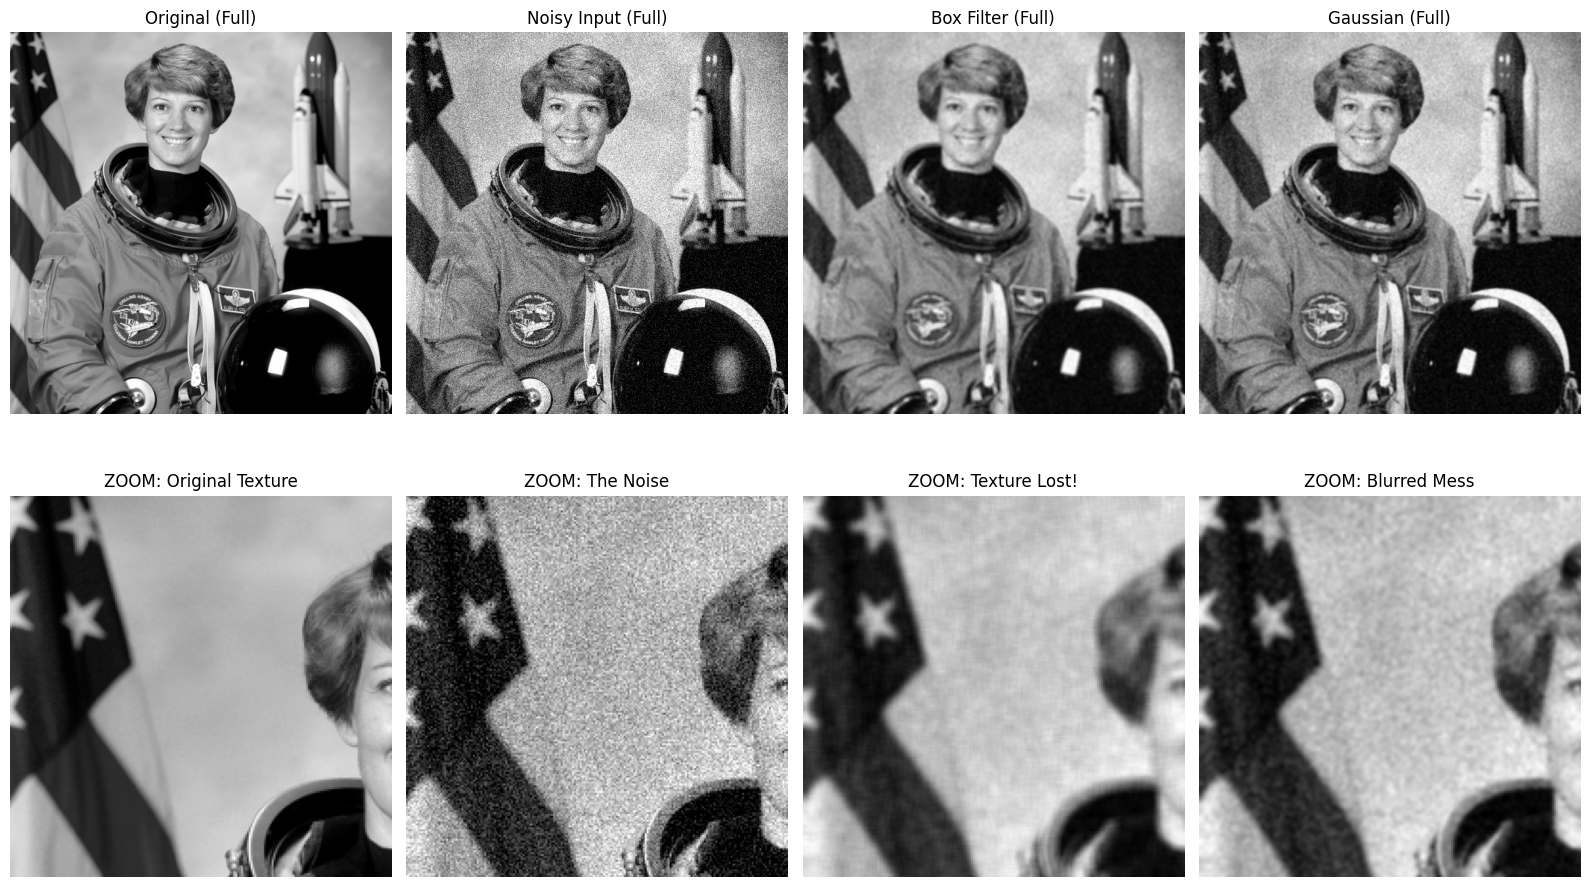

In [8]:
# 5. Visualization
plt.figure(figsize=(16, 10))

# Row 1: Full Image Context
plt.subplot(2, 4, 1); plt.imshow(clean_img, cmap='gray'); plt.title("Original (Full)"); plt.axis('off')
plt.subplot(2, 4, 2); plt.imshow(noisy_img, cmap='gray'); plt.title("Noisy Input (Full)"); plt.axis('off')
plt.subplot(2, 4, 3); plt.imshow(blur_box, cmap='gray'); plt.title("Box Filter (Full)"); plt.axis('off')
plt.subplot(2, 4, 4); plt.imshow(blur_gauss, cmap='gray'); plt.title("Gaussian (Full)"); plt.axis('off')

# Row 2: The "Texture Test" (Zoomed In)
plt.subplot(2, 4, 5); plt.imshow(crop_clean, cmap='gray'); plt.title("ZOOM: Original Texture"); plt.axis('off')
plt.subplot(2, 4, 6); plt.imshow(crop_noisy, cmap='gray'); plt.title("ZOOM: The Noise"); plt.axis('off')
plt.subplot(2, 4, 7); plt.imshow(crop_box, cmap='gray'); plt.title("ZOOM: Texture Lost!"); plt.axis('off')
plt.subplot(2, 4, 8); plt.imshow(crop_gauss, cmap='gray'); plt.title("ZOOM: Blurred Mess"); plt.axis('off')

plt.tight_layout()
plt.show()